# Notebook 94 - final MATLAB vs Python Kalman comparison

Compare MATLAB final `ANG`, `PEN`, and `FL` against Python normal fixed-R Kalman and Python adaptive anisotropic Kalman after the notebook-90 localmax fallback was promoted into code.

In [1]:
from pathlib import Path
import subprocess
import sys

from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent

SCRIPT = ROOT / 'scripts' / 'evaluate_final_kalman_matlab_comparison.py'
OUT = ROOT / 'results' / 'notebook94_final_kalman_matlab_comparison'
SCRIPT, OUT

(PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_final_kalman_matlab_comparison.py'),
 PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook94_final_kalman_matlab_comparison'))

## Run or refresh comparison

Default target is the MATLAB-backed `UltraTimTrack_test.mp4` / `slow_low_01_DOWN_tracked_Q=001.mat` pair used by notebooks 89-93. If the strict output is missing, this cell runs the updated strict pipeline with `--hough-localmax-fallback`, adaptive Kalman, and fixed-Kalman comparison enabled.

In [2]:
RUN_PIPELINE_IF_NEEDED = True

cmd = [sys.executable, str(SCRIPT)]
if not RUN_PIPELINE_IF_NEEDED:
    cmd.append('--no-run')

# For a reversed-fascicle video with a matching MATLAB .mat, override the defaults like this:
# cmd += [
#     '--video', str(ROOT / 'data/raw/june30_1.AVI'),
#     '--roi-path', str(ROOT / 'data/rois/june30_1_rois.json'),
#     '--matlab-result', str(ROOT / 'data/matlab/YOUR_JUNE30_MATLAB_RESULT.mat'),
#     '--name', 'june30_1_localmax_adaptive',
#     '--fas-angle-min', '-40', '--fas-angle-max', '-5',
# ]

completed = subprocess.run(cmd, cwd=ROOT, check=True)
completed.returncode

# Notebook 94 - final MATLAB vs Python Kalman comparison

This run compares MATLAB final outputs against Python normal fixed-R Kalman and Python adaptive anisotropic Kalman.

## Configuration

- Video: `/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4`
- MATLAB result: `/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat`
- Strict result NPZ: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook94_final_kalman_matlab_comparison/python_localmax_adaptive/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz`
- Hough localmax fallback: enabled, mass_below_10deg >= 0.25, gap_to_lower_deg >= 4.0
- Fascicle angle range: 5 to 60 deg
- Compared frames: 2666 with Python offset 1
- Localmax fallback frames in raw run: 175

## Key metrics

- Best ANG_deg: `Python normal Kalman` RMSE 0.8345 deg
- Best PEN_deg: `Python adaptive Kalman` RMSE 0.8412 deg
- Best FL_mm: `Python adaptive Kalman` RMSE 1.4347 mm

## Outputs

- Metrics CSV: `/

0

## Summary

In [3]:
display(Markdown((OUT / 'notebook94_summary.md').read_text()))

# Notebook 94 - final MATLAB vs Python Kalman comparison

This run compares MATLAB final outputs against Python normal fixed-R Kalman and Python adaptive anisotropic Kalman.

## Configuration

- Video: `/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4`
- MATLAB result: `/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat`
- Strict result NPZ: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook94_final_kalman_matlab_comparison/python_localmax_adaptive/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz`
- Hough localmax fallback: enabled, mass_below_10deg >= 0.25, gap_to_lower_deg >= 4.0
- Fascicle angle range: 5 to 60 deg
- Compared frames: 2666 with Python offset 1
- Localmax fallback frames in raw run: 175

## Key metrics

- Best ANG_deg: `Python normal Kalman` RMSE 0.8345 deg
- Best PEN_deg: `Python adaptive Kalman` RMSE 0.8412 deg
- Best FL_mm: `Python adaptive Kalman` RMSE 1.4347 mm

## Outputs

- Metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook94_final_kalman_matlab_comparison/kalman_matlab_metrics.csv`
- Per-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook94_final_kalman_matlab_comparison/kalman_matlab_per_frame.csv`
- Over-time plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook94_final_kalman_matlab_comparison/kalman_matlab_over_time.png`


In [4]:
import pandas as pd

metrics = pd.read_csv(OUT / 'kalman_matlab_metrics.csv')
metrics

,method,signal,unit,n,bias,mae,rmse,corr
0,Python normal Kalman,ANG_deg,deg,2666,0.751822,0.755776,0.834506,0.998201
1,Python adaptive Kalman,ANG_deg,deg,2666,0.955453,0.956514,1.037439,0.998391
2,Python normal Kalman,PEN_deg,deg,2666,-0.671152,0.761608,0.933975,0.995492
3,Python adaptive Kalman,PEN_deg,deg,2666,-0.467520,0.691527,0.841236,0.995816
4,Python normal Kalman,FL_mm,mm,2666,0.562939,1.258781,1.535758,0.997696
5,Python adaptive Kalman,FL_mm,mm,2666,0.194521,1.237889,1.434718,0.997754


## ANG, PEN, and FL over time

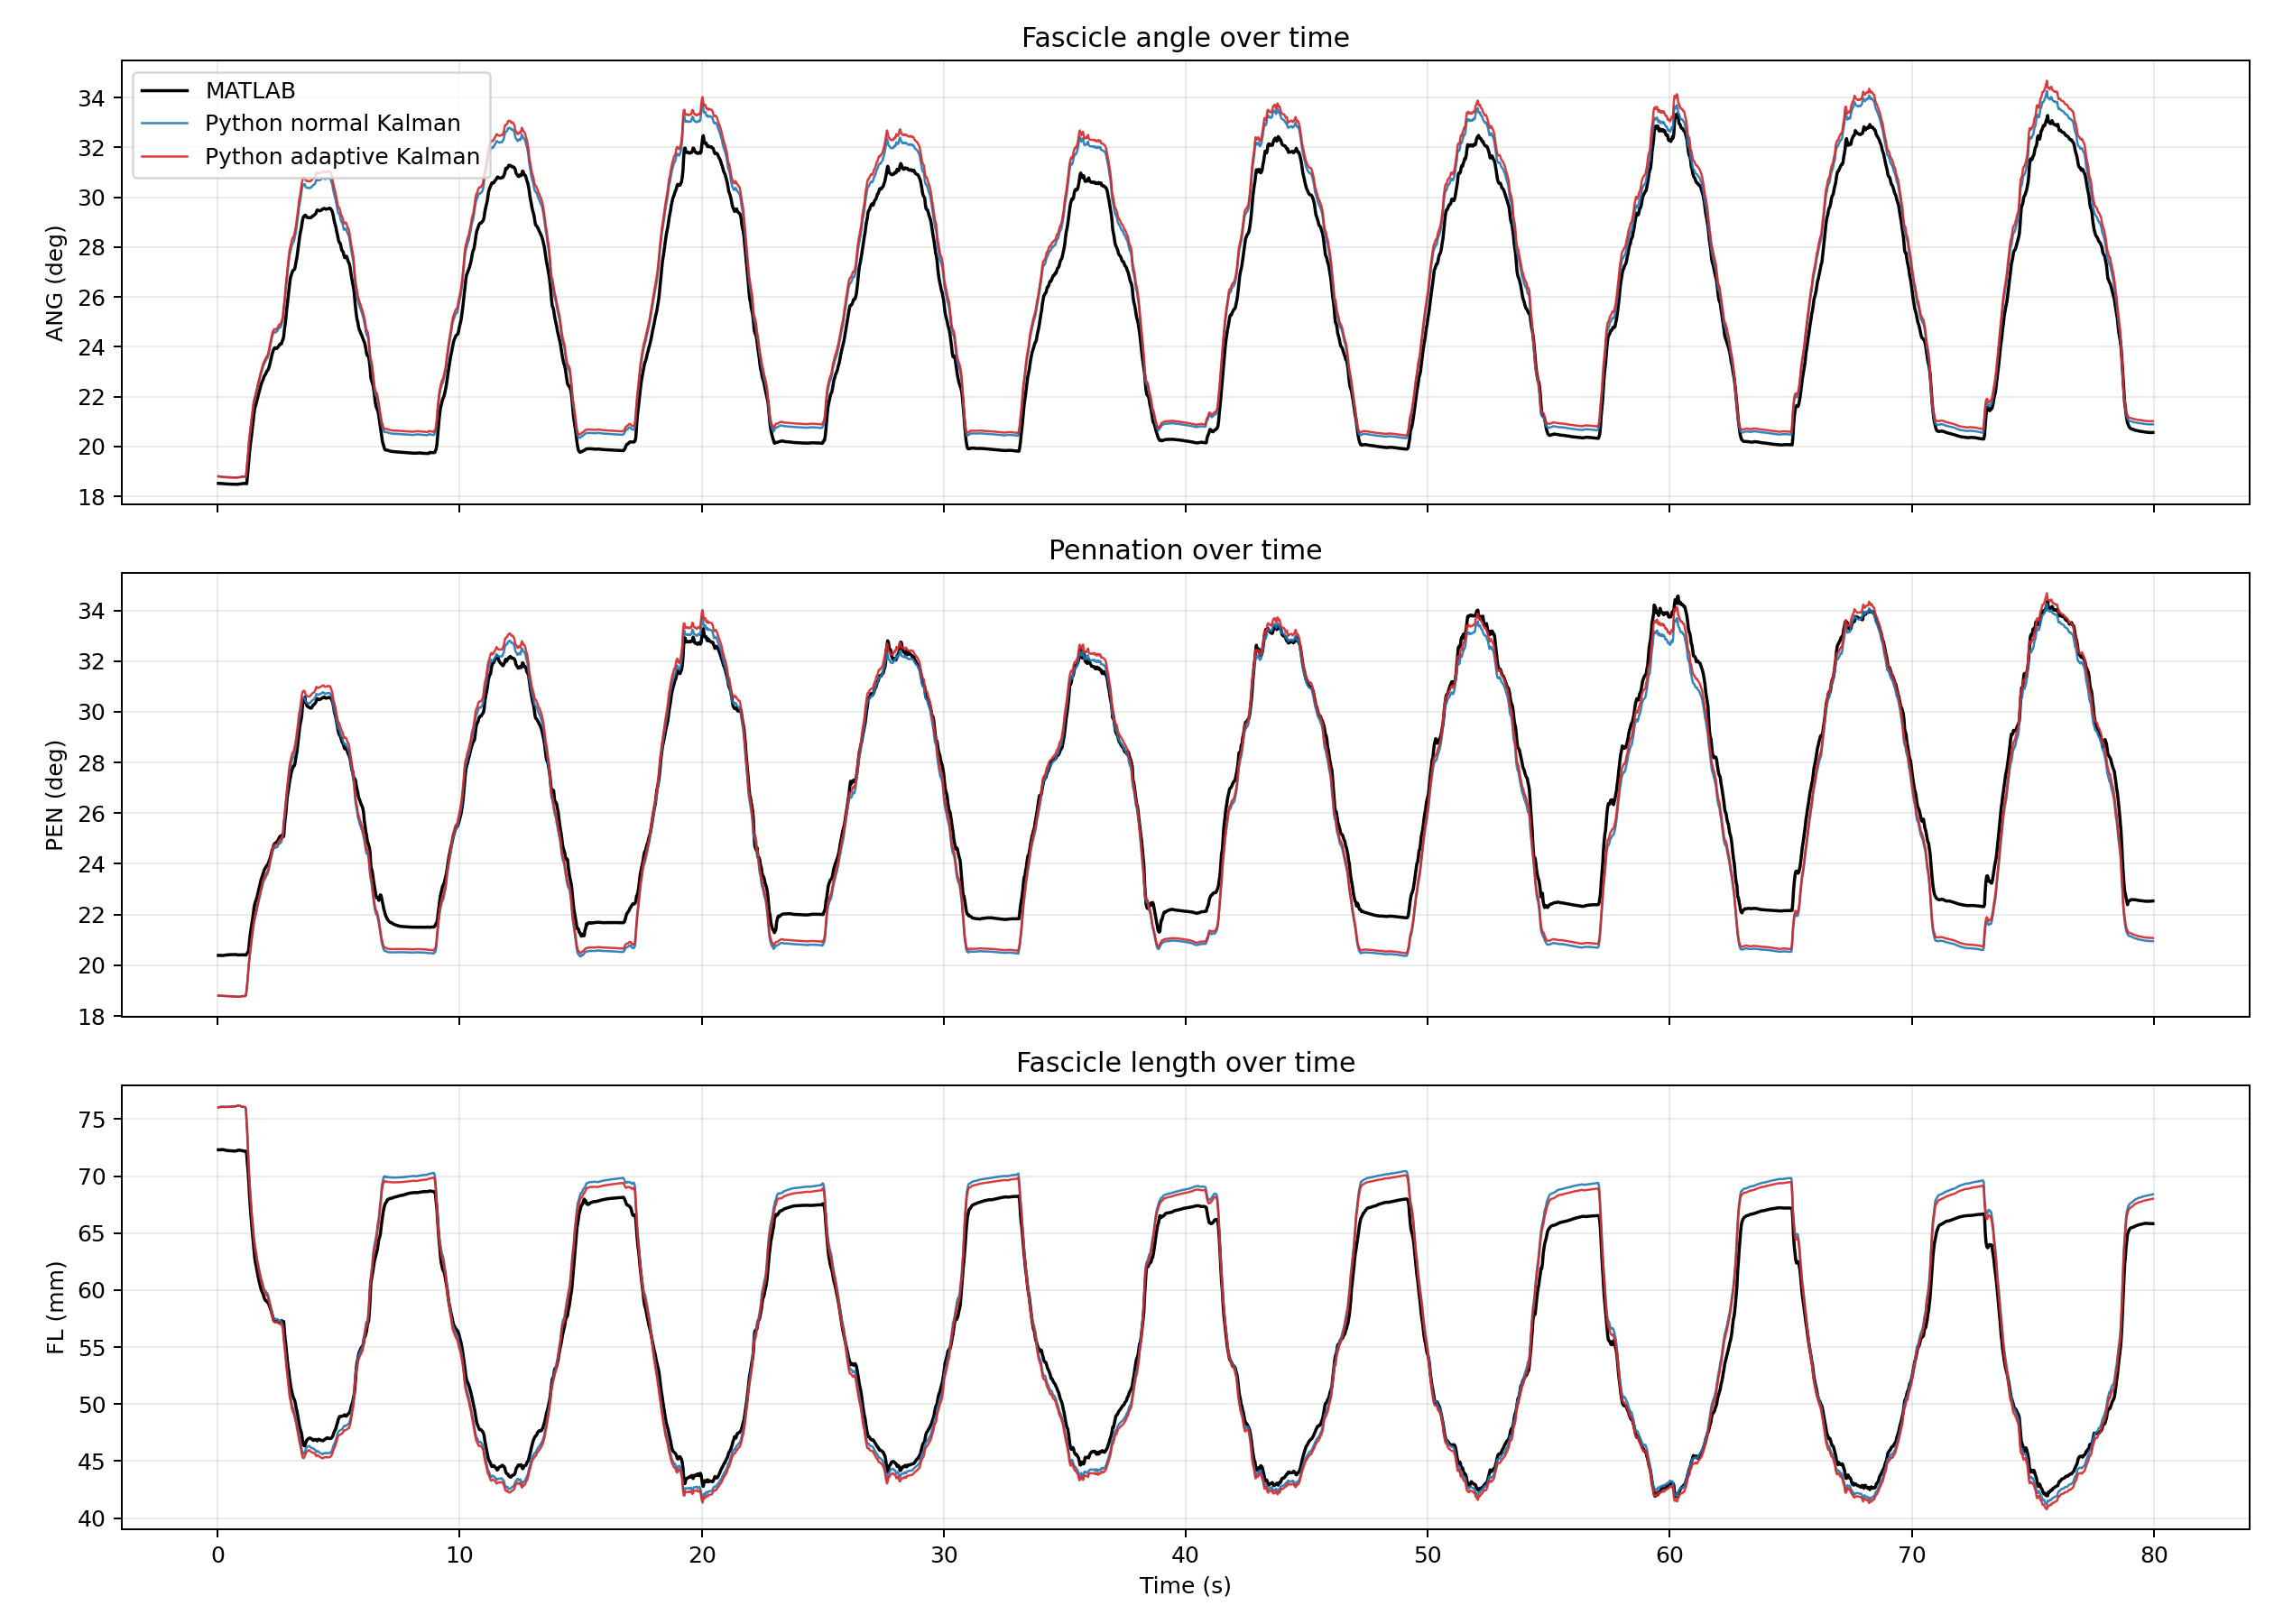

In [5]:
display(Image(filename=str(OUT / 'kalman_matlab_over_time.png')))